In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Present period

In [2]:
iyear = 2000
fyear = 2019
variables = ['t2m','FLH','tcwv','ivt','vimd','tp','sf','rf', 'R']

In [3]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
path = '/bettik/PROJECTS/pr-regional-climate/bricej/paper/'

var_trends = {}

for var in variables:
    var_trends[var] = {}
    for month in months :
        monthly_trends = pd.read_csv(f'{path}{var}_era5_{month}_trends_HIMAPgrouped_regions_{iyear}-{fyear}.csv')
        var_trends[var][month] = monthly_trends

In [4]:
domains = ["Tien Shan", "Pamir Alay", "Pamir", "Hindu Kush", "Karakoram", "Kunlun", "Spiti Lahaul", "Central Himalaya",
           "Bhutan", "Nyainqentangla", "Inner TP"]

# valeur de la pente
var_slopes = {}
for var in variables:
    var_slopes[var] = {}
    for dom in domains:
        var_slopes[var][dom] = {}
        for month in months:
            var_slopes[var][dom][month] = var_trends[var][month].loc[var_trends[var][month]['region'] == dom, 'slope'].values[0] * 10 # *10 -> per decade

# valeur de la pvalue
var_pvalue = {}
for var in variables:
    var_pvalue[var] = {}
    for dom in domains:
        var_pvalue[var][dom] = {}
        for month in months:
            var_pvalue[var][dom][month] = var_trends[var][month].loc[var_trends[var][month]['region'] == dom, 'pvalue'].values[0]
            

# All period

In [5]:
iyear2 = 1960
fyear2 = 2019

In [6]:
var_trends_all_period = {}

for var in variables:
    var_trends_all_period[var] = {}
    for month in months :
        monthly_trends = pd.read_csv(f'{path}{var}_era5_{month}_trends_HIMAPgrouped_regions_{iyear2}-{fyear2}.csv')
        var_trends_all_period[var][month] = monthly_trends

In [7]:
# valeur de la pente
var_slopes_all_period = {}
for var in variables:
    var_slopes_all_period[var] = {}
    for dom in domains:
        var_slopes_all_period[var][dom] = {}
        for month in months:
            var_slopes_all_period[var][dom][month] = var_trends_all_period[var][month].loc[var_trends_all_period[var][month]['region'] == dom, 'slope'].values[0] * 10 # *10 -> per decade

# valeur de la pvalue
var_pvalue_all_period = {}
for var in variables:
    var_pvalue_all_period[var] = {}
    for dom in domains:
        var_pvalue_all_period[var][dom] = {}
        for month in months:
            var_pvalue_all_period[var][dom][month] = var_trends_all_period[var][month].loc[var_trends_all_period[var][month]['region'] == dom, 'pvalue'].values[0]
            

# Saison d'accumulation

In [8]:
accu = {"Tien Shan" : ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
        "Pamir Alay" : ['Jan', 'Feb', 'Mar', 'Apr'],
        "Pamir" : ['Jan', 'Feb', 'Mar', 'Apr'],
        "Hindu Kush" : ['Feb', 'Mar', 'Apr'],
        "Karakoram" : ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
        "Kunlun" : ['May', 'Jun', 'Jul', 'Aug', 'Sep'],
        "Spiti Lahaul" : ['Jan', 'Feb', 'Mar'],
        "Central Himalaya" : ['Jan', 'Feb', 'Mar', 'Apr'],
        "Bhutan" : ['Jan', 'Feb', 'Mar', 'Apr'],
        "Nyainqentangla" : ['Feb', 'Mar', 'Apr', 'May'],
        "Inner TP" : ['Feb', 'Mar', 'Apr', 'May', 'Jun']}

month_to_num = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}



# Plot

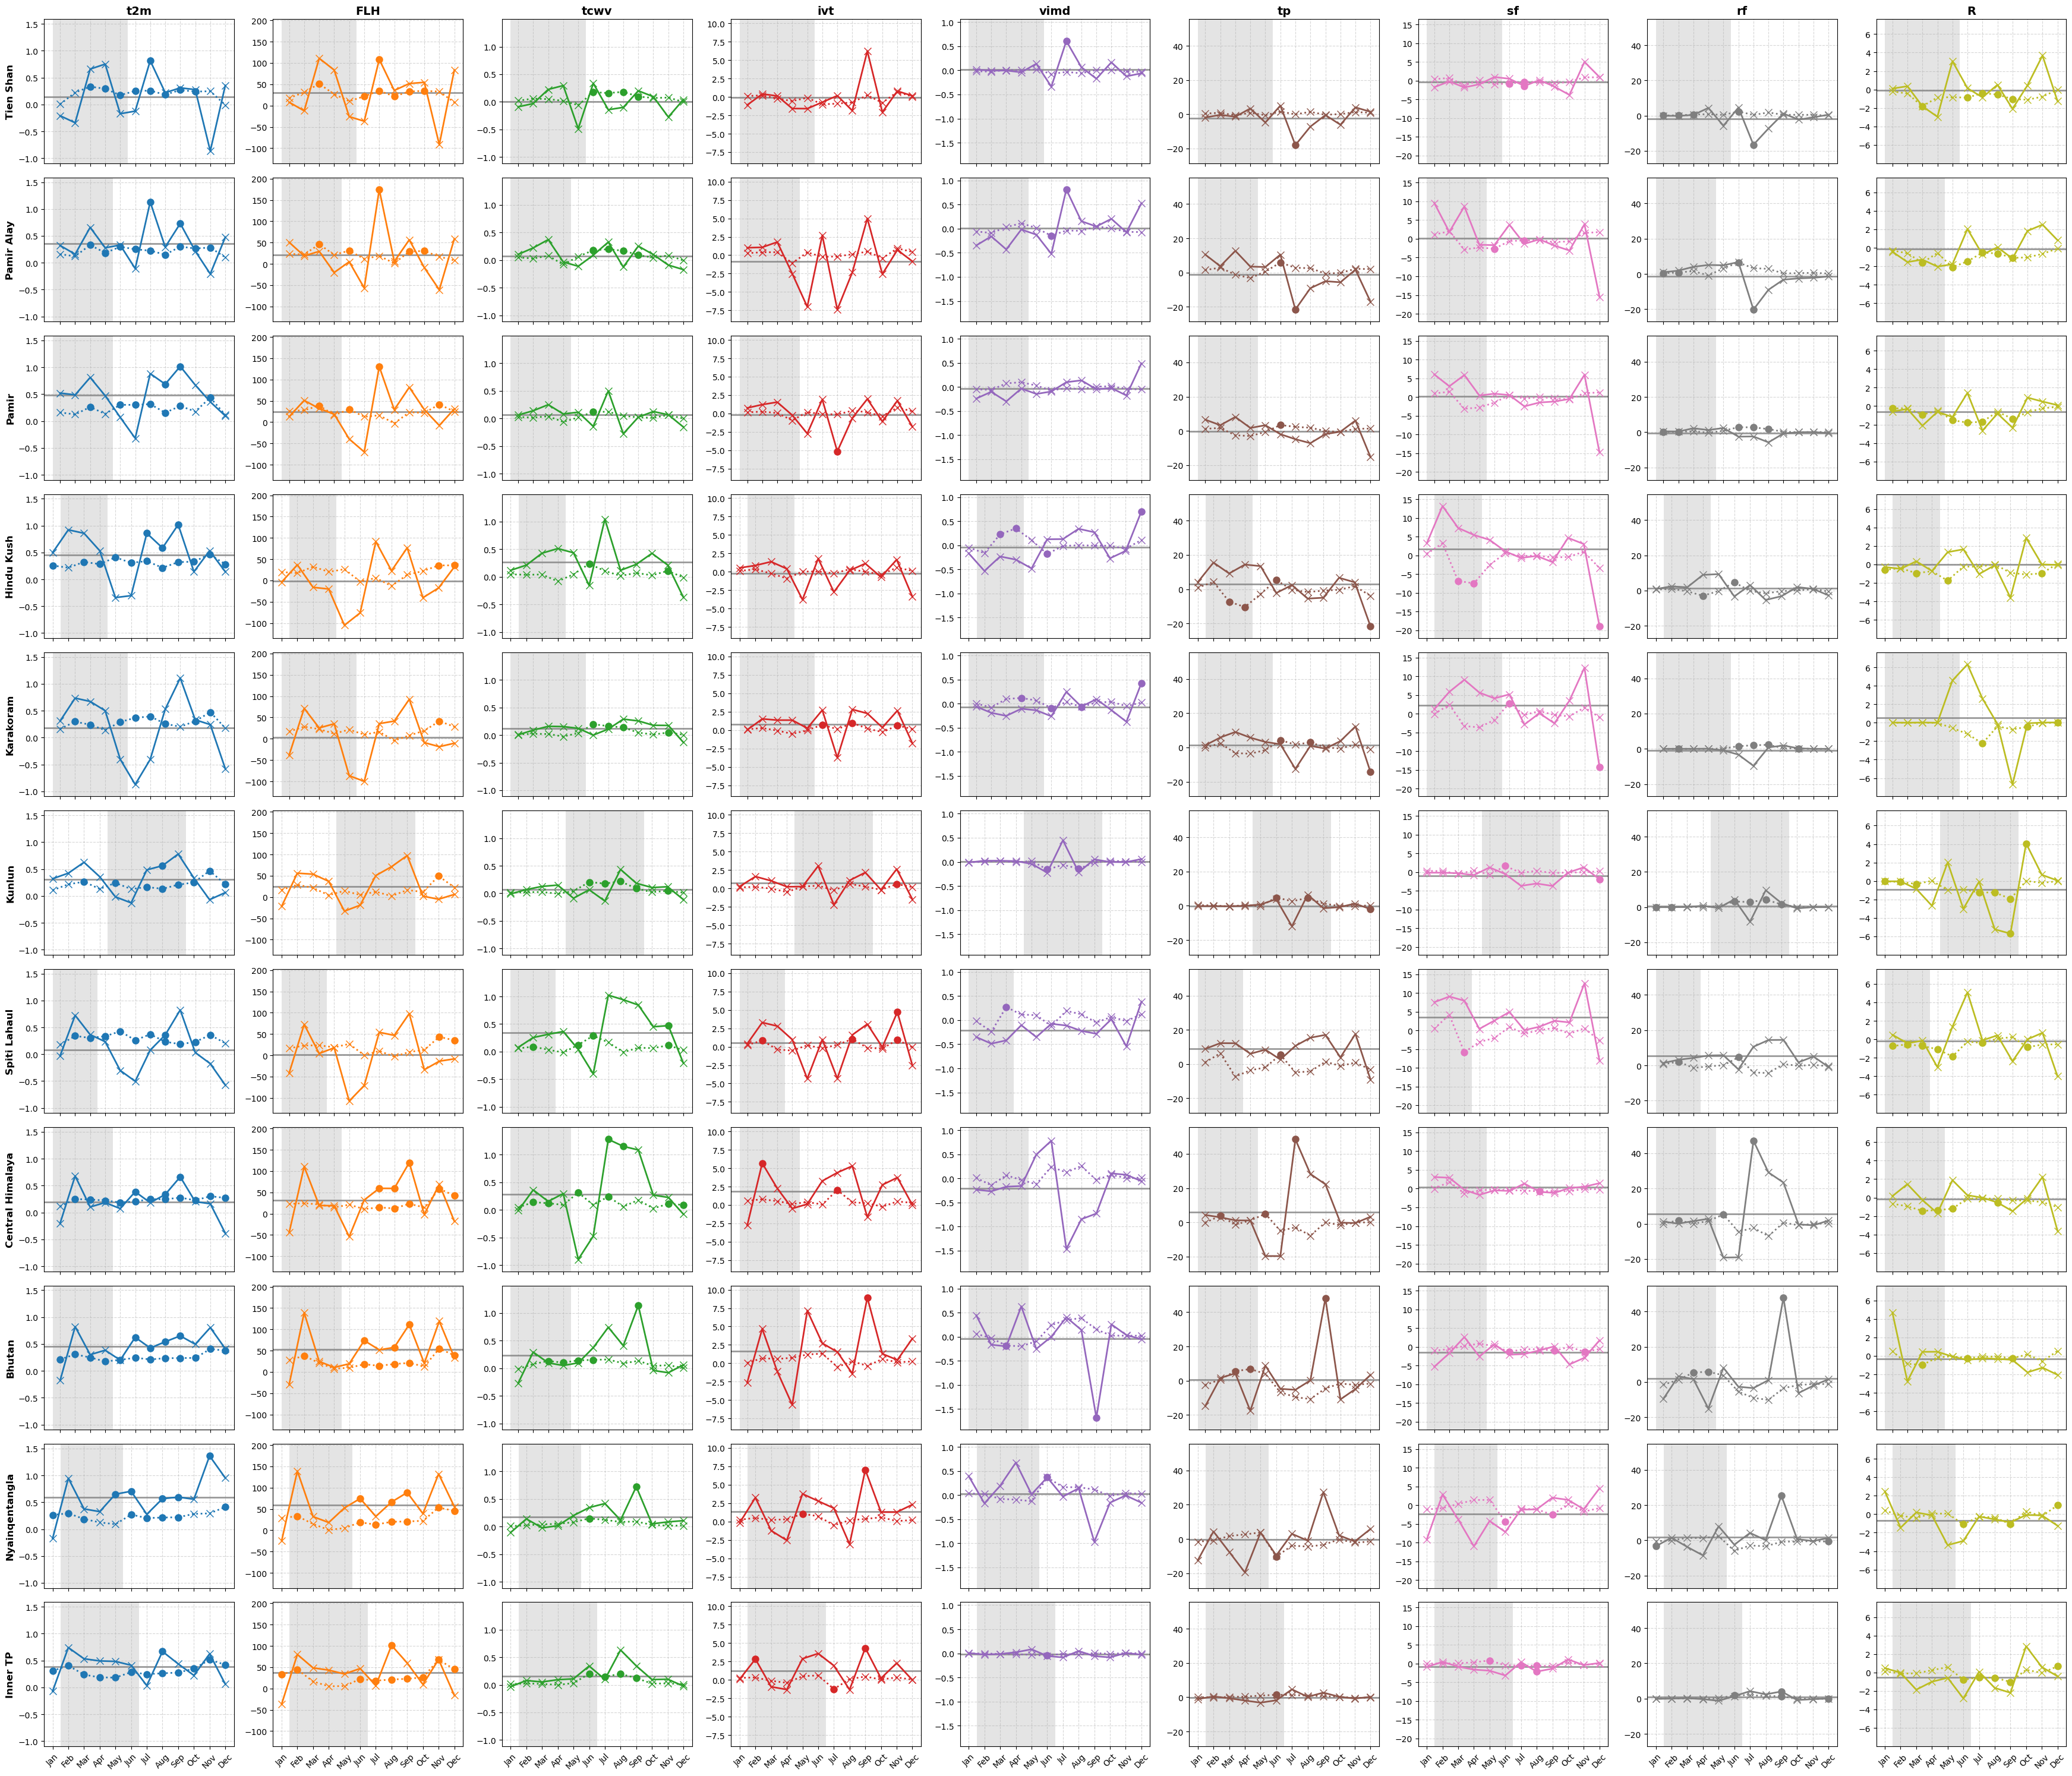

In [11]:
fig, axes = plt.subplots(11, 9, figsize=(35, 30))

# limites Y par colonne
ylims = {}
for var in variables:
    all_slopes = []
    for dom in domains:
        all_slopes.extend(
            [var_slopes[var][dom][m] for m in months]
        )
    ymin = min(all_slopes)
    ymax = max(all_slopes)
    margin = 0.1 * (ymax - ymin)
    ylims[var] = (ymin - margin, ymax + margin)
    
colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple',
    'tab:brown',
    'tab:pink',
    'tab:gray',
    'tab:olive'
]

for i, dom in enumerate(domains): # ligne
    for j, var in enumerate(variables): # colonne
        
        ax = axes[i,j]
        color = colors[j]

        # saison d'accumulation
        accu_months = accu[dom]
        accu_nums = [month_to_num[m] for m in accu_months]
        
        slopes = [var_slopes[var][dom][m] for m in months]
        pvalues = [var_pvalue[var][dom][m] for m in months]
        
        # all period 1960-2019
        slopes_all_period = [var_slopes_all_period[var][dom][m] for m in months]
        pvalues_all_period = [var_pvalue_all_period[var][dom][m] for m in months]
    
        markers = ['x' if p > 0.05 else 'o' for p in pvalues] # 2000-2019
        markers2 = ['x' if p > 0.05 else 'o' for p in pvalues_all_period] # 1960-2019

        # mean value of slopes
        mean = np.mean(slopes)
        ax.axhline(y=mean, linestyle='-', linewidth=2, color='gray', alpha=0.8) # 2000-2019
        
        # ligne pointillée pour relier les trends
        ax.plot(
            range(1, 13),
            slopes,
            linestyle='-',
            linewidth=2,
            color=color
        )

        # ligne pleine pour all period pour relier les trends
        ax.plot(
            range(1, 13),
            slopes_all_period,
            linestyle=':',
            linewidth=2,
            color=color
        )
    
        # points mois par mois, marker en fonction de la pvalue
        for m_idx, month_num in enumerate(range(1, 13)): # m_idx de 0 à 11 et month_num de 1 à 12
            ax.plot(
                month_num,
                slopes[m_idx],
                marker=markers[m_idx],
                linestyle='None',
                markersize=8,
                color=color
            )

        # points mois par mois, marker en fonction de la pvalue de all period
        for m_idx, month_num in enumerate(range(1, 13)): # m_idx de 0 à 11 et month_num de 1 à 12
            ax.plot(
                month_num,
                slopes_all_period[m_idx],
                marker=markers2[m_idx],
                linestyle='None',
                markersize=8,
                color=color
            )

        # shading gris clair
        ax.axvspan(
            min(accu_nums) - 0.5,
            max(accu_nums) + 0.5,
            color='lightgray',
            alpha=0.6,
            zorder=0,
            ec=None
        )

        # y lim pour chaque colonne 
        ax.set_ylim(ylims[var])
        
        # titre des variables
        if i == 0:
            ax.set_title(var, fontsize=14, weight='bold')

        # titre des régions
        if j == 0:
            ax.set_ylabel(dom, fontsize=12, weight='bold')

        # labe des mois que sur la dernière ligne
        ax.set_xticks(range(1, 13))
        if i == len(domains) - 1:
            ax.set_xticklabels(months, rotation=45, fontsize=10)
        else:
            ax.tick_params(labelbottom=False)

        # yticks & labelticks partout
        ax.tick_params(axis='y',labelleft=True)
        
        ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Percentage for tcwv, ivt, tp, sf, rf

## Present

In [12]:
var_trends2 = {}

for var in variables:
    var_trends2[var] = {}
    for month in months :
        
        if var in ['t2m','FLH','vimd','R']:
            monthly_trends = pd.read_csv(f'{path}{var}_era5_{month}_trends_HIMAPgrouped_regions_{iyear}-{fyear}.csv')
        elif var in ['tcwv','ivt','tp','sf','rf']:
            monthly_trends = pd.read_csv(f'{path}{var}_era5_{month}_percentage_trends_HIMAPgrouped_regions_{iyear}-{fyear}.csv')
            
        var_trends2[var][month] = monthly_trends

In [13]:
# valeur de la pente
var_slopes2 = {}
for var in variables:
    var_slopes2[var] = {}
    for dom in domains:
        var_slopes2[var][dom] = {}
        for month in months:
            var_slopes2[var][dom][month] = var_trends2[var][month].loc[var_trends2[var][month]['region'] == dom, 'slope'].values[0] * 10 # *10 -> per decade

# valeur de la pvalue
var_pvalue2 = {}
for var in variables:
    var_pvalue2[var] = {}
    for dom in domains:
        var_pvalue2[var][dom] = {}
        for month in months:
            var_pvalue2[var][dom][month] = var_trends2[var][month].loc[var_trends2[var][month]['region'] == dom, 'pvalue'].values[0]

## All period

In [14]:
var_trends_all_period2 = {}

for var in variables:
    var_trends_all_period2[var] = {}
    for month in months :

        if var in ['t2m','FLH','vimd','R']:
            monthly_trends = pd.read_csv(f'{path}{var}_era5_{month}_trends_HIMAPgrouped_regions_{iyear2}-{fyear2}.csv')
        elif var in ['tcwv','ivt','tp','sf','rf']:
            monthly_trends = pd.read_csv(f'{path}{var}_era5_{month}_percentage_trends_HIMAPgrouped_regions_{iyear2}-{fyear2}.csv')
        
        var_trends_all_period2[var][month] = monthly_trends

In [15]:
# valeur de la pente
var_slopes_all_period2 = {}
for var in variables:
    var_slopes_all_period2[var] = {}
    for dom in domains:
        var_slopes_all_period2[var][dom] = {}
        for month in months:
            var_slopes_all_period2[var][dom][month] = var_trends_all_period2[var][month].loc[var_trends_all_period2[var][month]['region'] == dom, 'slope'].values[0] * 10 # *10 -> per decade

# valeur de la pvalue
var_pvalue_all_period2 = {}
for var in variables:
    var_pvalue_all_period2[var] = {}
    for dom in domains:
        var_pvalue_all_period2[var][dom] = {}
        for month in months:
            var_pvalue_all_period2[var][dom][month] = var_trends_all_period2[var][month].loc[var_trends_all_period2[var][month]['region'] == dom, 'pvalue'].values[0]
            

## Plot

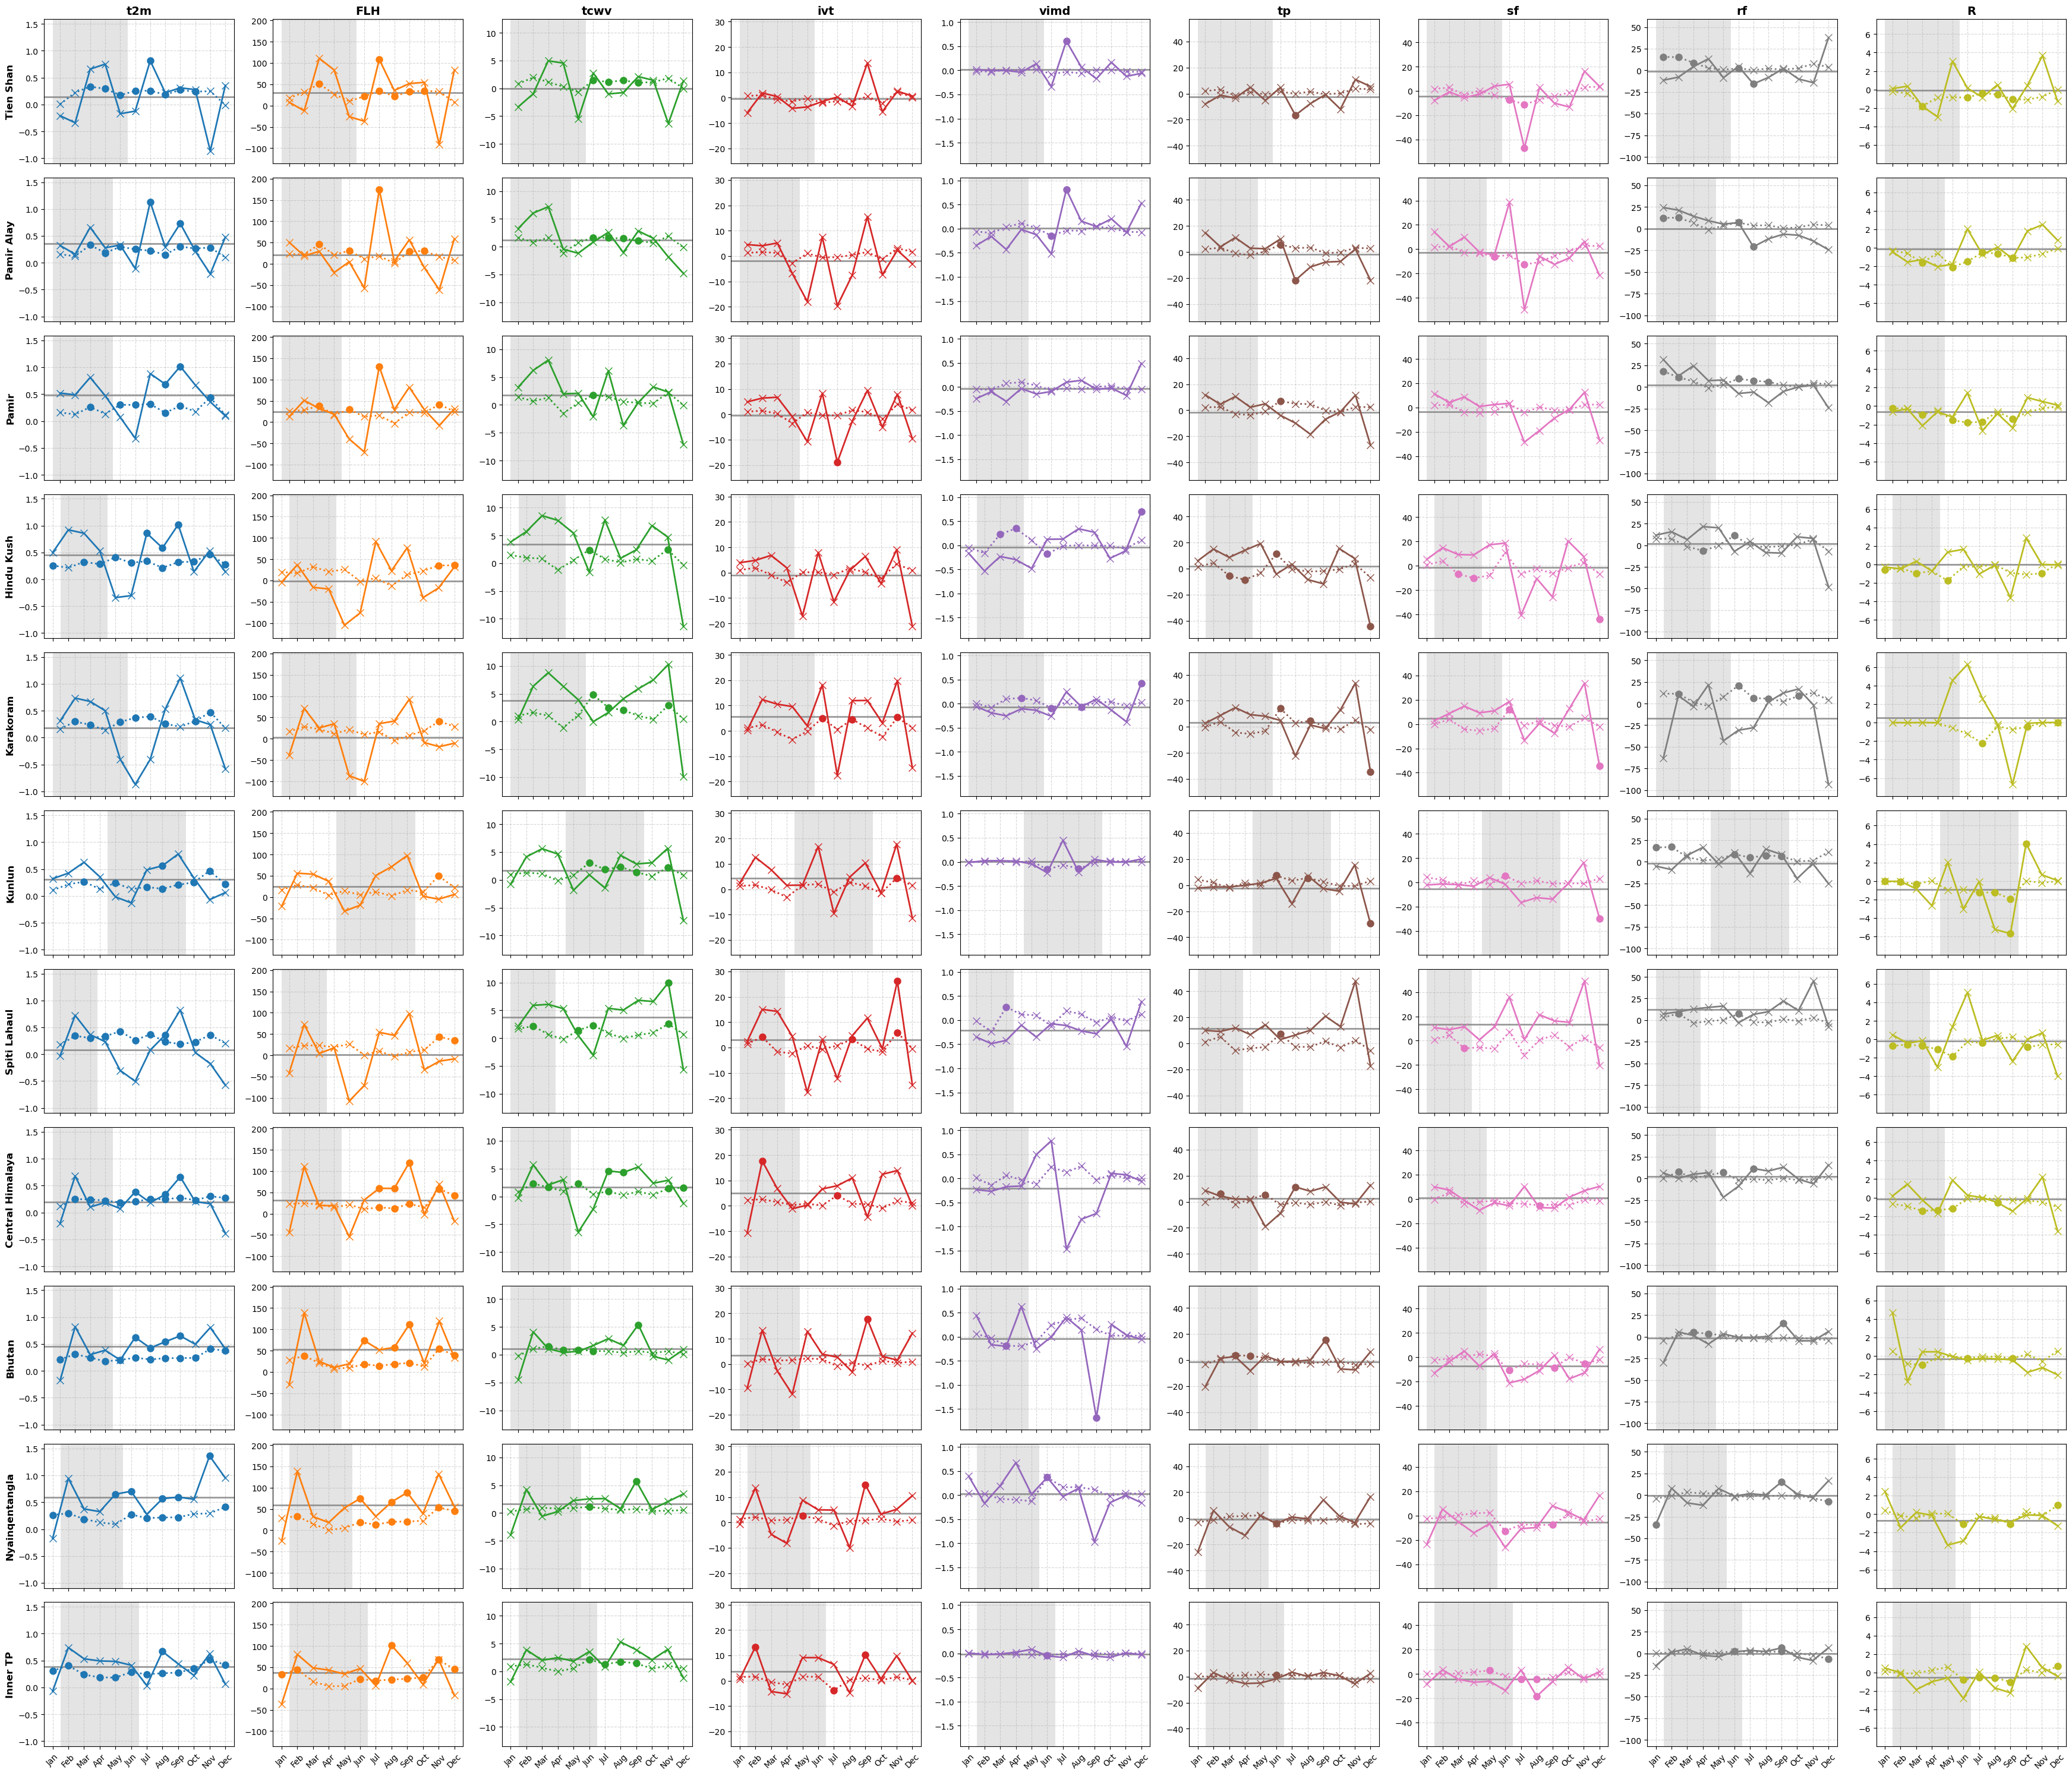

In [16]:
fig, axes = plt.subplots(11, 9, figsize=(35, 30))

# limites Y par colonne
ylims = {}
for var in variables:
    all_slopes = []
    for dom in domains:
        all_slopes.extend(
            [var_slopes2[var][dom][m] for m in months]
        )
    ymin = min(all_slopes)
    ymax = max(all_slopes)
    margin = 0.1 * (ymax - ymin)
    ylims[var] = (ymin - margin, ymax + margin)
    
colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple',
    'tab:brown',
    'tab:pink',
    'tab:gray',
    'tab:olive'
]

for i, dom in enumerate(domains): # ligne
    for j, var in enumerate(variables): # colonne
        
        ax = axes[i,j]
        color = colors[j]

        # saison d'accumulation
        accu_months = accu[dom]
        accu_nums = [month_to_num[m] for m in accu_months]
        
        slopes = [var_slopes2[var][dom][m] for m in months]
        pvalues = [var_pvalue2[var][dom][m] for m in months]

        # all period 1960-2019
        slopes_all_period = [var_slopes_all_period2[var][dom][m] for m in months]
        pvalues_all_period = [var_pvalue_all_period2[var][dom][m] for m in months]
        
        markers = ['x' if p > 0.05 else 'o' for p in pvalues]
        markers2 = ['x' if p > 0.05 else 'o' for p in pvalues_all_period] # 1960-2019

        # mean value of slopes
        mean = np.mean(slopes)
        ax.axhline(y=mean, linestyle='-', linewidth=2, color='gray', alpha=0.8) # 2000-2019
        
        # ligne pointillée pour relier les trends
        ax.plot(
            range(1, 13),
            slopes,
            linestyle='-',
            linewidth=2,
            color=color
        )

        # ligne pleine pour all period pour relier les trends
        ax.plot(
            range(1, 13),
            slopes_all_period,
            linestyle=':',
            linewidth=2,
            color=color
        )
    
        # points mois par mois, marker en fonction de la pvalue
        for m_idx, month_num in enumerate(range(1, 13)): # m_idx de 0 à 11 et month_num de 1 à 12
            ax.plot(
                month_num,
                slopes[m_idx],
                marker=markers[m_idx],
                linestyle='None',
                markersize=8,
                color=color
            )

        # points mois par mois, marker en fonction de la pvalue de all period
        for m_idx, month_num in enumerate(range(1, 13)): # m_idx de 0 à 11 et month_num de 1 à 12
            ax.plot(
                month_num,
                slopes_all_period[m_idx],
                marker=markers2[m_idx],
                linestyle='None',
                markersize=8,
                color=color
            )

        # shading gris clair
        ax.axvspan(
            min(accu_nums) - 0.5,
            max(accu_nums) + 0.5,
            color='lightgray',
            alpha=0.6,
            zorder=0,
            ec=None
        )

        # y lim pour chaque colonne 
        ax.set_ylim(ylims[var])
        
        # titre des variables
        if i == 0:
            ax.set_title(var, fontsize=14, weight='bold')

        # titre des régions
        if j == 0:
            ax.set_ylabel(dom, fontsize=12, weight='bold')

        # labe des mois que sur la dernière ligne
        ax.set_xticks(range(1, 13))
        if i == len(domains) - 1:
            ax.set_xticklabels(months, rotation=45, fontsize=10)
        else:
            ax.tick_params(labelbottom=False)

        # yticks & labelticks partout
        ax.tick_params(axis='y',labelleft=True)
        
        ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()